In [1]:
import pandas as pd
import numpy as np
import re
from collections import Counter
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

df = pd.read_csv('all_comments_ottawa.csv', names=['comments'])

df.head()

,comments
0,Chambre confortable mais décoration un peu dém...
1,Le spa propose un traitement signature exclusi...
2,Un séjour correct mais qui ne justifie pas ple...
3,The laundry service express saved our gala din...
4,L'exposition de collection d'art contemporain ...


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5946 entries, 0 to 5945
Data columns (total 1 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   comments  5946 non-null   object
dtypes: object(1)
memory usage: 46.6+ KB


In [3]:
df.duplicated().sum()

np.int64(0)

In [4]:
def clean_text(text):
    text = text.lower()  # Minuscules
    text = re.sub(r'[^a-zà-ÿ\s]', '', text)  # Garder lettres et accents
    text = re.sub(r'\s+', ' ', text).strip()  # Espaces multiples
    return text

In [5]:
df['comments'] = df['comments'].apply(clean_text)

In [6]:
df.head()

,comments
0,chambre confortable mais décoration un peu dém...
1,le spa propose un traitement signature exclusi...
2,un séjour correct mais qui ne justifie pas ple...
3,the laundry service express saved our gala din...
4,lexposition de collection dart contemporain de...


In [7]:
df['comments'] = df['comments'].apply(word_tokenize)
print(f"Exemple : {df['comments'].iloc[0]}")

Exemple : ['chambre', 'confortable', 'mais', 'décoration', 'un', 'peu', 'démodée', 'le', 'petitdéjeuner', 'est', 'bon', 'mais', 'sans', 'originalité', 'particulière']


In [8]:
stop_fr = set(stopwords.words('french'))
stop_en = set(stopwords.words('english'))
stop = stop_fr.union(stop_en)

def remove_stopwords(tokens):
    return [t for t in tokens if t not in stop and len(t) > 2]

In [9]:
df['comments'] = df['comments'].apply(remove_stopwords)
print(f"Exemple après suppression des stop words : {df['comments'].iloc[0]}")

Exemple après suppression des stop words : ['chambre', 'confortable', 'décoration', 'peu', 'démodée', 'petitdéjeuner', 'bon', 'sans', 'originalité', 'particulière']


In [10]:
lemmatizer = WordNetLemmatizer()

def lemmatize(tokens):
    return [lemmatizer.lemmatize(t) for t in tokens]

df['comments'] = df['comments'].apply(lemmatize)
print(f"Lemmes : {df['comments'].iloc[0]}")

Lemmes : ['chambre', 'confortable', 'décoration', 'peu', 'démodée', 'petitdéjeuner', 'bon', 'sans', 'originalité', 'particulière']


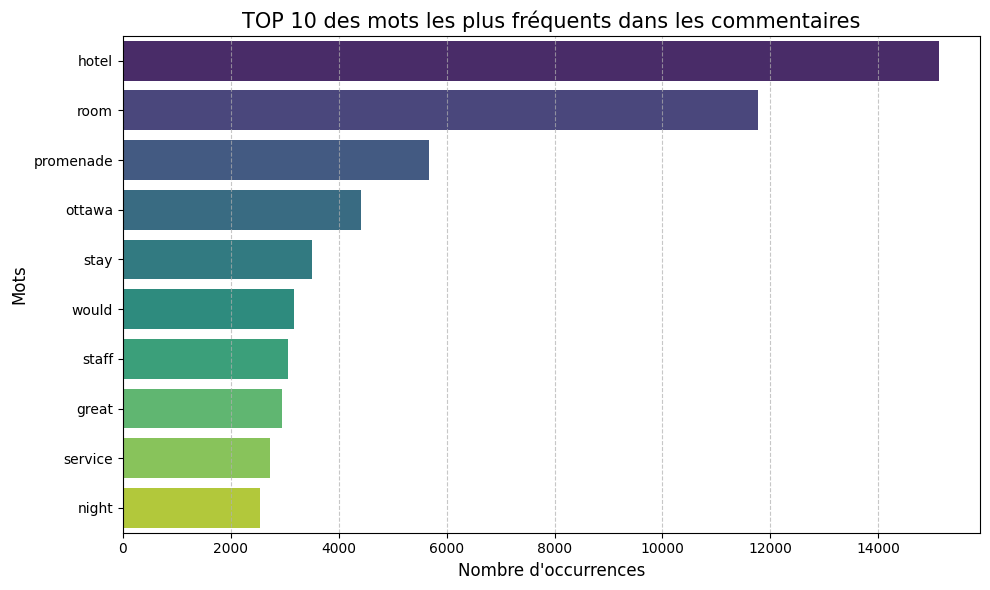

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

all_words = [w for tokens in df['comments'] for w in tokens]
word_freq = Counter(all_words)

# On récupère les 10 mots les plus fréquents
top_10 = word_freq.most_common(10)
mots = [item[0] for item in top_10]
frequences = [item[1] for item in top_10]

plt.figure(figsize=(10, 6))
sns.barplot(x=frequences, y=mots, hue=mots, palette='viridis', legend=False)

plt.title('TOP 10 des mots les plus fréquents dans les commentaires', fontsize=15)
plt.xlabel('Nombre d\'occurrences', fontsize=12)
plt.ylabel('Mots', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [12]:
# transformer les listes de tokens en chaînes de caractères
df['comment_str'] = df['comments'].apply(lambda x: ' '.join(x))
df['comment_str'].head()

0    chambre confortable décoration peu démodée pet...
1    spa propose traitement signature exclusif déve...
2    séjour correct justifie pleinement classement ...
3    laundry service express saved gala dinner foll...
4    lexposition collection dart contemporain lhôte...
Name: comment_str, dtype: object

In [13]:
vectorizer_bigram = CountVectorizer(ngram_range=(2, 2))
X_bigram = vectorizer_bigram.fit_transform(df['comment_str'])

bigram_counts = pd.DataFrame(X_bigram.toarray(), columns=vectorizer_bigram.get_feature_names_out())

# Sommer les occurrences de chaque bigram
bigram_freq = bigram_counts.sum().sort_values(ascending=False)

# Afficher les 10 bigrams les plus fréquents
top_10_bigrams = bigram_freq.head(10).reset_index()
top_10_bigrams.columns = ['Bigramme', 'Frequence']

print("Top 10 Bigrammes:\n", top_10_bigrams)

Top 10 Bigrammes:
               Bigramme  Frequence
0      hotel promenade       5527
1        byward market        942
2      parliament hill        922
3         stayed hotel        814
4           stay hotel        695
5         rideau canal        666
6         room service        513
7           room small        502
8           front desk        470
9  parliament building        470


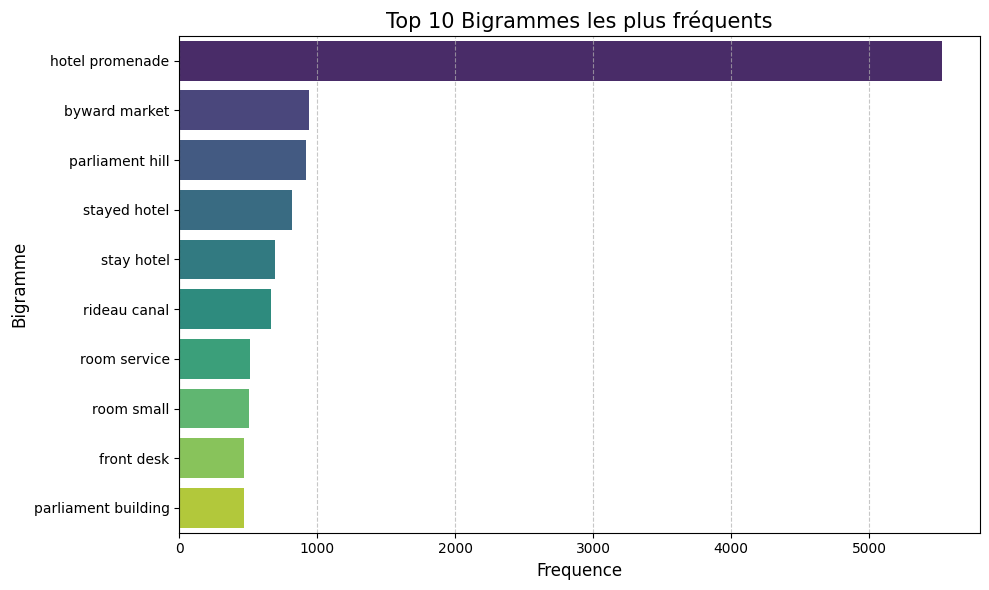

In [14]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Frequence', y='Bigramme', hue='Bigramme', data=top_10_bigrams, palette='viridis', legend=False)
plt.title('Top 10 Bigrammes les plus fréquents', fontsize=15)
plt.xlabel('Frequence', fontsize=12)
plt.ylabel('Bigramme', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [15]:
vectorizer_trigram = CountVectorizer(ngram_range=(3, 3))
X_trigram = vectorizer_trigram.fit_transform(df['comment_str'])

trigram_counts = pd.DataFrame(X_trigram.toarray(), columns=vectorizer_trigram.get_feature_names_out())

# Sommer les occurrences de chaque trigram
trigram_freq = trigram_counts.sum().sort_values(ascending=False)

# Afficher les 10 trigrams les plus fréquents
top_10_trigrams = trigram_freq.head(10).reset_index()
top_10_trigrams.columns = ['Trigramme', 'Frequence']

print("Top 10 Trigrammes:\n", top_10_trigrams)

Top 10 Trigrammes:
                   Trigramme  Frequence
0    stayed hotel promenade        710
1      stay hotel promenade        525
2           tick tock diner        223
3   national gallery canada        222
4  view parliament building        196
5   staying hotel promenade        168
6    first impression hotel        164
7          lobby nice dated        155
8         soon walked lobby        155
9         walked lobby nice        155


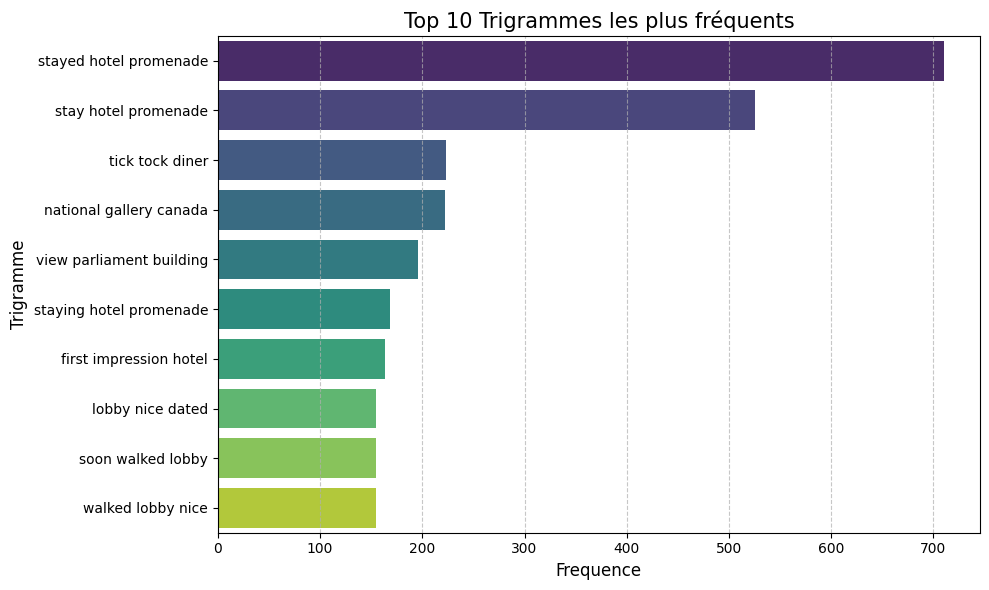

In [16]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Frequence', y='Trigramme', hue='Trigramme', data=top_10_trigrams, palette='viridis', legend=False)
plt.title('Top 10 Trigrammes les plus fréquents', fontsize=15)
plt.xlabel('Frequence', fontsize=12)
plt.ylabel('Trigramme', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [17]:
tfidf_vectorizer = TfidfVectorizer(max_df=0.95, min_df=2, max_features=1000)
tfidf_matrix = tfidf_vectorizer.fit_transform(df['comment_str'])

print(f"dimension de la matrice TF-IDF: {tfidf_matrix.shape}")

dimension de la matrice TF-IDF: (5946, 1000)


In [18]:
from sklearn.decomposition import LatentDirichletAllocation

# Définir le nombre de thèmes (topics) à extraire
num_topics = 5

# Initialiser et entrainer le modèle LDA
lda_model = LatentDirichletAllocation(n_components=num_topics, random_state=42)
lda_matrix = lda_model.fit_transform(tfidf_matrix)

# Afficher les mots les plus représentatifs de chaque thème
def display_topics(model, feature_names, no_top_words):
    for topic_idx, topic in enumerate(model.components_): # On trie les indices des mots par importance et On récupère les mots correspondants
        print(f"Theme {topic_idx + 1}:")
        print(" ".join([feature_names[i]
                        for i in topic.argsort()[:-no_top_words - 1:-1]]))

no_top_words = 10
tfidf_feature_names = tfidf_vectorizer.get_feature_names_out()
display_topics(lda_model, tfidf_feature_names, no_top_words)

print(f"Dimensions de la matrice LDA: {lda_matrix.shape}")

Theme 1:
room hotel promenade would stay one night lobby service ottawa
Theme 2:
très chambre sans bien chambres hôtel personnel plus peu lhôtel
Theme 3:
service malgré suite private menu offer sans promenade standard restaurant
Theme 4:
hotel promenade spa stay room ottawa service history staff beautiful
Theme 5:
hotel room great ottawa location parliament staff promenade good clean
Dimensions de la matrice LDA: (5946, 5)


In [19]:
from textblob import TextBlob

def get_sentiment_score(text):
    return TextBlob(text).sentiment.polarity

df['sentiment_score'] = df['comment_str'].apply(get_sentiment_score)
df[['comment_str', 'sentiment_score']].head()

,comment_str,sentiment_score
0,chambre confortable décoration peu démodée pet...,0.0
1,spa propose traitement signature exclusif déve...,0.0
2,séjour correct justifie pleinement classement ...,0.0
3,laundry service express saved gala dinner foll...,0.0
4,lexposition collection dart contemporain lhôte...,0.0


In [20]:
df['sentiment_score'].value_counts()

sentiment_score
 0.000000    760
 0.500000     52
 0.100000     37
 0.400000     29
 0.333333     25
            ... 
 0.284583      1
-0.450000      1
 0.379063      1
 0.233929      1
 0.194222      1
Name: count, Length: 4253, dtype: int64

In [21]:
def classify_sentiment(score):
    if score > 0.1:
        return 'Positive'
    elif score < -0.1:
        return 'Negative'
    else:
        return 'Neutral'

df['sentiment'] = df['sentiment_score'].apply(classify_sentiment)

print("Sentiment classification applied.")
print("Sentiment distribution:")
print(df['sentiment'].value_counts())

Sentiment classification applied.
Sentiment distribution:
sentiment
Positive    4272
Neutral     1508
Negative     166
Name: count, dtype: int64


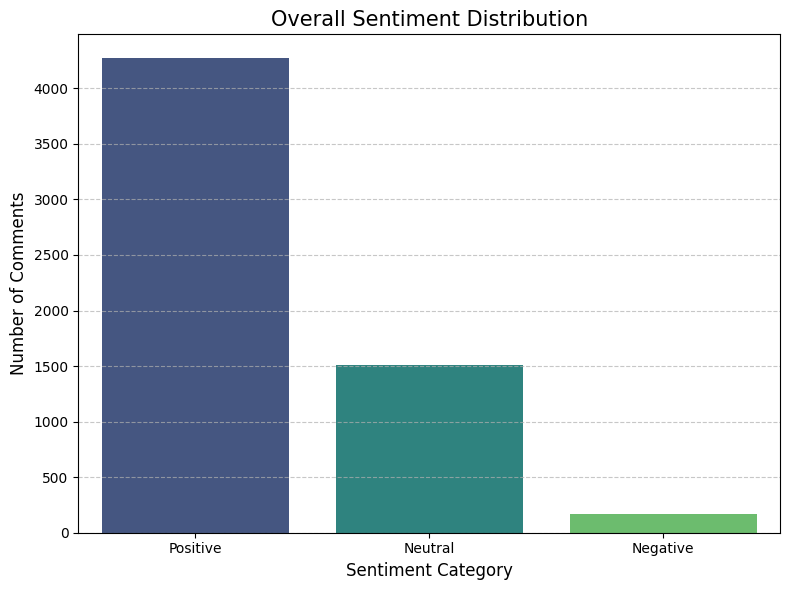

In [22]:
sentiment_counts = df['sentiment'].value_counts().reset_index()
sentiment_counts.columns = ['Sentiment Category', 'Number of Comments']

plt.figure(figsize=(8, 6))
sns.barplot(x='Sentiment Category', y='Number of Comments', hue='Sentiment Category', data=sentiment_counts, palette='viridis', legend=False)
plt.title('Overall Sentiment Distribution', fontsize=15)
plt.xlabel('Sentiment Category', fontsize=12)
plt.ylabel('Number of Comments', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

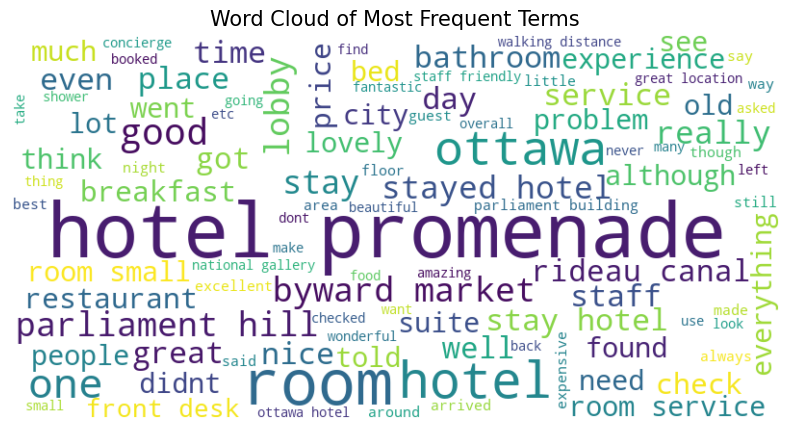

In [23]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Concatener tous les commentaires prétraités en une seule chaîne de caractères
all_comments_text = ' '.join([' '.join(tokens) for tokens in df['comments']])

# Instancier un objet WordCloud
wordcloud = WordCloud(width=800, height=400, background_color='white', max_words=100).generate(all_comments_text)

# Afficher le nuage de mots
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Most Frequent Terms', fontsize=15)
plt.show()